<a href="https://colab.research.google.com/github/dewi-ops/Data-Analytic-and-Infrastucture/blob/main/DAI_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", None)

In [3]:
from google.colab import files
uploaded = files.upload()

Saving raw_retail_transactions.csv to raw_retail_transactions.csv


In [5]:
df = pd.read_csv("raw_retail_transactions.csv")
df.head()


,transaction_id,order_date,customer_id,customer_name,segment,product_id,product_name,category,sub_category,region,sales,quantity,discount,profit,payment_method
0,TRX001,2023-01-05,C001,Andi Wijaya,Consumer,P001,Laptop Pro 14,Technology,Laptop,West,14500000,1,0.10,2500000,Credit Card
1,TRX002,2023/01/06,C002,Budi Santoso,Corporate,P002,Office Chair,Furniture,Chair,East,3500000,2,0.05,500000,Cash
2,TRX003,05-01-2023,C003,Siti Aminah,Consumer,P003,Wireless Mouse,Technology,Accessories,Central,250000,3,NaN,75000,E-Wallet
3,TRX004,2023-01-07,C001,Andi Wijaya,Consumer,P004,Standing Desk,Furniture,Table,West,7800000,1,0.15,1200000,Credit Card
4,TRX005,2023-01-08,C004,Rina Kurnia,Home Office,P005,Printer Ink,Office Supplies,Consumables,South,450000,5,0.00,90000,Bank Transfer


In [7]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  10 non-null     object 
 1   order_date      10 non-null     object 
 2   customer_id     10 non-null     object 
 3   customer_name   10 non-null     object 
 4   segment         10 non-null     object 
 5   product_id      10 non-null     object 
 6   product_name    10 non-null     object 
 7   category        10 non-null     object 
 8   sub_category    10 non-null     object 
 9   region          10 non-null     object 
 10  sales           10 non-null     int64  
 11  quantity        10 non-null     int64  
 12  discount        8 non-null      float64
 13  profit          10 non-null     int64  
 14  payment_method  10 non-null     object 
dtypes: float64(1), int64(3), object(11)
memory usage: 1.3+ KB


,sales,quantity,discount,profit
count,1.000000e+01,10.000000,8.000000,1.000000e+01
mean,5.000000e+06,2.700000,0.087500,7.030000e+05
std,5.609615e+06,2.869379,0.064087,9.246236e+05
min,5.000000e+04,1.000000,0.000000,-2.000000e+05
25%,3.000000e+05,1.000000,0.050000,5.625000e+04
50%,3.500000e+06,1.500000,0.075000,2.950000e+05
75%,7.150000e+06,2.750000,0.112500,1.100000e+06
max,1.450000e+07,10.000000,0.200000,2.500000e+06


In [8]:
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
df[df['order_date'].isna()]


,transaction_id,order_date,customer_id,customer_name,segment,product_id,product_name,category,sub_category,region,sales,quantity,discount,profit,payment_method
1,TRX002,NaT,C002,Budi Santoso,Corporate,P002,Office Chair,Furniture,Chair,East,3500000,2,0.05,500000,Cash
2,TRX003,NaT,C003,Siti Aminah,Consumer,P003,Wireless Mouse,Technology,Accessories,Central,250000,3,NaN,75000,E-Wallet


In [9]:
df.isna().sum()
df['discount'] = df['discount'].fillna(0)

In [10]:
df.duplicated().sum()
df = df.drop_duplicates()

In [11]:
df[df['profit'] < 0]
df['loss_flag'] = df['profit'].apply(lambda x: 1 if x < 0 else 0)

In [12]:
df['net_sales'] = df['sales'] * (1 - df['discount'])
df['order_month'] = df['order_date'].dt.month
df['order_year'] = df['order_date'].dt.year

In [13]:
df['segment'] = df['segment'].str.lower().str.strip()
df['payment_method'] = df['payment_method'].str.lower().str.strip()
segment_encoding = df['segment'].astype('category').cat.codes
df['segment_code'] = segment_encoding

In [14]:
df.groupby('region')['net_sales'].sum().sort_values(ascending=False)

,net_sales
region,
West,24620000.0
East,19900000.0
South,675000.0
Central,300000.0


In [15]:
df.groupby('category')['profit'].sum()

,profit
category,
Furniture,1500000
Office Supplies,105000
Technology,5425000


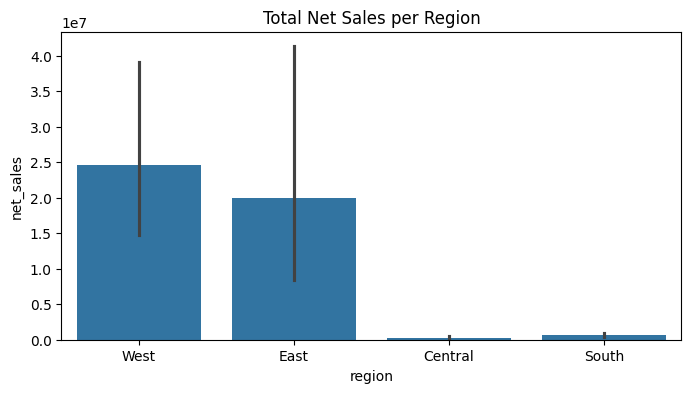

In [16]:
plt.figure(figsize=(8,4))
sns.barplot(
 data=df,
 x='region',
 y='net_sales',
 estimator=sum
)
plt.title("Total Net Sales per Region")
plt.show()

In [17]:
df.to_csv("cleaned_retail_dataset.csv", index=False)